# Projeto de Análise Exploratória de Vendas

## Objetivo: Este projeto tem como objetivo realizar uma análise exploratória de dados de vendas utilizando Python. Para isso, foi gerada uma base de dados fictícia contendo informações sobre produtos, categorias, clientes, estados e faturamento. A partir desses dados foram desenvolvidas análises estatísticas e visualizações para identificar padrões e extrair insights.

## Geração dos Dados

In [1]:
!pip install -q -U watermark

#importar as bibliotecas
import pandas as pd  

import numpy as np  

import matplotlib.pyplot as plt  

import seaborn as sns  

import random  

from datetime import datetime, timedelta 

# Importa a função FuncFormatter para formatar os eixos
from matplotlib.ticker import FuncFormatter

np.random.seed(42)
random.seed(42)

# Comando do Jupyter Notebook que permite exibir gráficos diretamente no notebook
%matplotlib inline  

%reload_ext watermark
%watermark -a "Eduarda Diorio"
%watermark --iversions    

# Instalar uma versão específica de um pacote
!pip install -q pandas==2.3.1


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Author: Eduarda Diorio

matplotlib: 3.10.6
numpy     : 2.3.5
pandas    : 2.3.1
seaborn   : 0.13.2




[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Gera um DataFrame do Pandas com dados de vendas fictícios.
def dados_ficticios(num_registros = 600):
   

    # Mensagem inicial indicando a quantidade de registros a serem gerados
    print(f"\nIniciando a geração de {num_registros} registros de vendas...")

    # Dicionário com produtos, suas categorias e preços
    produtos = {
        'Laptop Gamer': {'categoria': 'Eletrônicos', 'preco': 7500.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 550.00},
        'Monitor Ultrawide': {'categoria': 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de Vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hardware', 'preco': 600.00}
    }

    # Criar uma lista apenas com os nomes dos produtos
    lista_produtos = list(produtos.keys())

    # Dicionário com cidades e seus respectivos estados
    cidades_estados = {
        'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS', 'Salvador': 'BA', 'Curitiba': 'PR', 'Fortaleza': 'CE'
    }

    # Cria uma lista apenas com os nomes das cidades
    lista_cidades = list(cidades_estados.keys())

    # Lista que armazenará os registros de vendas
    dados_vendas = []

    # Define a data inicial dos pedidos
    data_inicial = datetime(2026, 1, 1)

    # Loop para gerar os registros de vendas
    for i in range(num_registros):
        
        # Seleciona aleatoriamente um produto
        produto_nome = random.choice(lista_produtos)

        # Seleciona aleatoriamente uma cidade
        cidade = random.choice(lista_cidades)

        # Gera uma quantidade de produtos vendida entre 1 e 7
        quantidade = np.random.randint(1, 8)

        # Calcula a data do pedido a partir da data inicial
        data_pedido = data_inicial + timedelta(days = int(i/5), hours = random.randint(0, 23))

        # Se o produto for Mouse ou Teclado, aplica desconto aleatório de até 10%
        if produto_nome in ['Mouse Vertical', 'Teclado Mecânico']:
            preco_unitario = produtos[produto_nome]['preco'] * np.random.uniform(0.9, 1.0)
        else:
            preco_unitario = produtos[produto_nome]['preco']

        # Adiciona um registro de venda à lista
        dados_vendas.append({
            'ID_Pedido': 1000 + i,
            'Data_Pedido': data_pedido,
            'Nome_Produto': produto_nome,
            'Categoria': produtos[produto_nome]['categoria'],
            'Preco_Unitario': round(preco_unitario, 2),
            'Quantidade': quantidade,
            'ID_Cliente': np.random.randint(100, 150),
            'Cidade': cidade,
            'Estado': cidades_estados[cidade]
        })
    
    # Mensagem final indicando que a geração terminou
    print("Geração de dados concluída.\n")

    # Retorna os dados no formato de DataFrame
    return pd.DataFrame(dados_vendas)

In [3]:
# Gerei os dados chamando a função da célula anterior
df_vendas = dados_ficticios(700)


Iniciando a geração de 700 registros de vendas...
Geração de dados concluída.



## Preparação dos Dados

In [4]:
type(df_vendas)

pandas.core.frame.DataFrame

In [5]:
#mostra linhas e colunas
df_vendas.shape

(700, 9)

In [6]:
# Mostra as 5 primeiras linhas do DataFrame
df_vendas.head() #posso por numero dentro

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 08:00:00,Laptop Gamer,Eletrônicos,7500.00,7,128,Curitiba,PR
1,1001,2026-01-01 04:00:00,Monitor Ultrawide,Eletrônicos,2800.00,7,142,Rio de Janeiro,RJ
2,1002,2026-01-01 23:00:00,Mouse Vertical,Acessórios,239.92,5,118,Curitiba,PR
3,1003,2026-01-01 13:00:00,Mouse Vertical,Acessórios,226.45,7,123,Salvador,BA
4,1004,2026-01-01 02:00:00,Laptop Gamer,Eletrônicos,7500.00,5,135,São Paulo,SP


In [7]:
#Informações gerais sobre o DataFrame
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       700 non-null    int64         
 1   Data_Pedido     700 non-null    datetime64[ns]
 2   Nome_Produto    700 non-null    object        
 3   Categoria       700 non-null    object        
 4   Preco_Unitario  700 non-null    float64       
 5   Quantidade      700 non-null    int64         
 6   ID_Cliente      700 non-null    int64         
 7   Cidade          700 non-null    object        
 8   Estado          700 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 49.3+ KB


In [8]:
# converter data para data time
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido'])

In [9]:
# Criar a coluna 'Faturamento' (preço x quantidade)
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [10]:
#Funçao lambda para criar status de entrega
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply(
    lambda estado:
        'Entrega Rápida' if estado in ['SP', 'RJ', 'MG']
        else 'Entrega Normal' if estado == 'PR'
        else 'Entrega Lenta')

In [11]:
# Informações gerais do DataFrame
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       700 non-null    int64         
 1   Data_Pedido     700 non-null    datetime64[ns]
 2   Nome_Produto    700 non-null    object        
 3   Categoria       700 non-null    object        
 4   Preco_Unitario  700 non-null    float64       
 5   Quantidade      700 non-null    int64         
 6   ID_Cliente      700 non-null    int64         
 7   Cidade          700 non-null    object        
 8   Estado          700 non-null    object        
 9   Faturamento     700 non-null    float64       
 10  Status_Entrega  700 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 60.3+ KB


## Análise dos Produtos

## Produtos Mais Vendidos

In [12]:
# Agrupa por nome do produto, soma a quantidade e ordena para encontrar os mais vendidos
top_10_produtos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)

# Exibir o resultado
top_10_produtos

Nome_Produto
SSD 1TB              390
Headset 7.1          378
Monitor Ultrawide    372
Cadeira Gamer        371
Teclado Mecânico     362
Mouse Vertical       347
Placa de Vídeo       339
Laptop Gamer         306
Name: Quantidade, dtype: int64

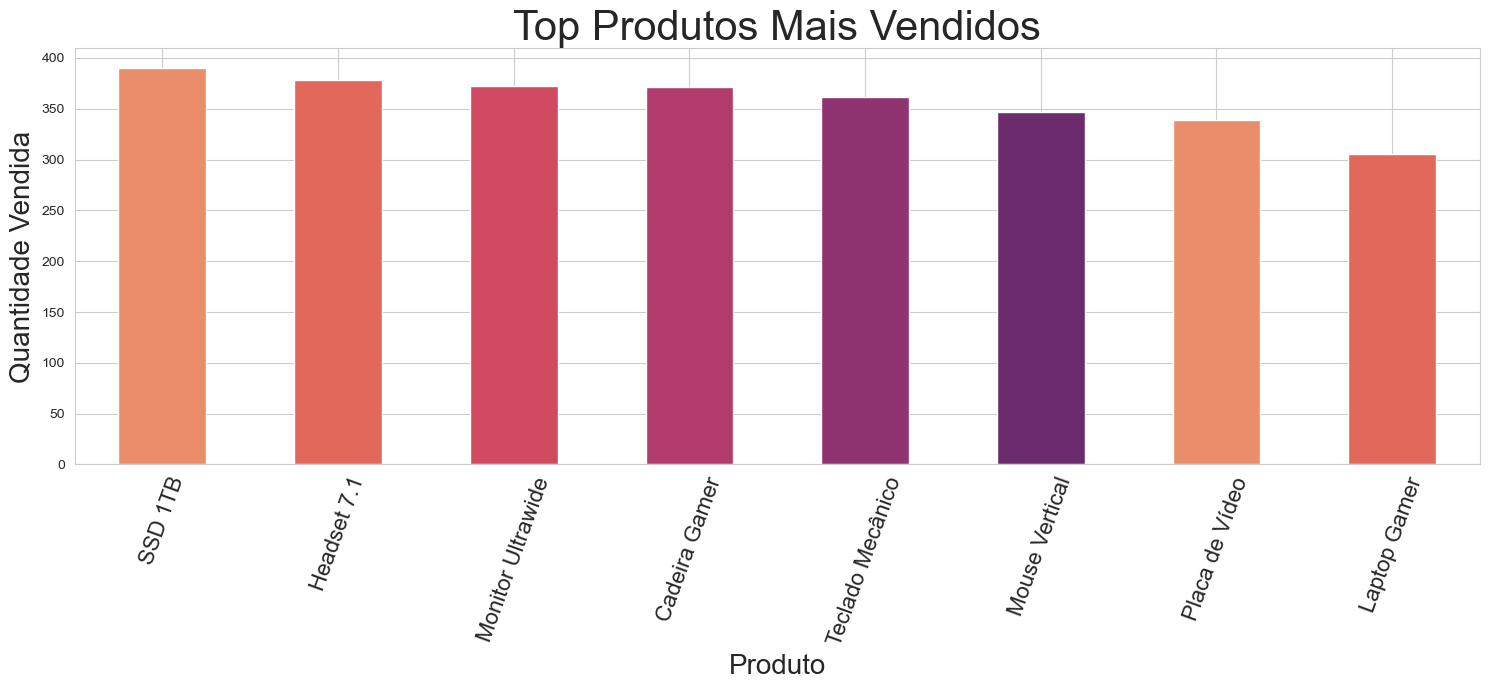

In [13]:
# Define um estilo para os gráficos
sns.set_style("whitegrid")

plt.figure(figsize = (15, 7))

top_10_produtos.sort_values(ascending = False).plot(kind = 'bar', color = sns.color_palette("flare"))

plt.title('Top Produtos Mais Vendidos', fontsize = 30)
plt.ylabel('Quantidade Vendida', fontsize = 20)
plt.xlabel('Produto', fontsize = 20)
plt.xticks(rotation=70, fontsize=16)

plt.savefig('top_10_produtos.png', dpi=300, bbox_inches='tight')

# rotaçao eixo x
plt.xticks(rotation = 70)

# Exibe o gráfico
plt.tight_layout()
plt.show()

## Maiores Faturamentos

In [14]:
top_10_faturamento = df_vendas.groupby('Nome_Produto')['Faturamento'].sum().sort_values(ascending = False).head()

top_10_faturamento

Nome_Produto
Laptop Gamer         2295000.0
Placa de Vídeo       1525500.0
Monitor Ultrawide    1041600.0
Cadeira Gamer         445200.0
Headset 7.1           302400.0
Name: Faturamento, dtype: float64

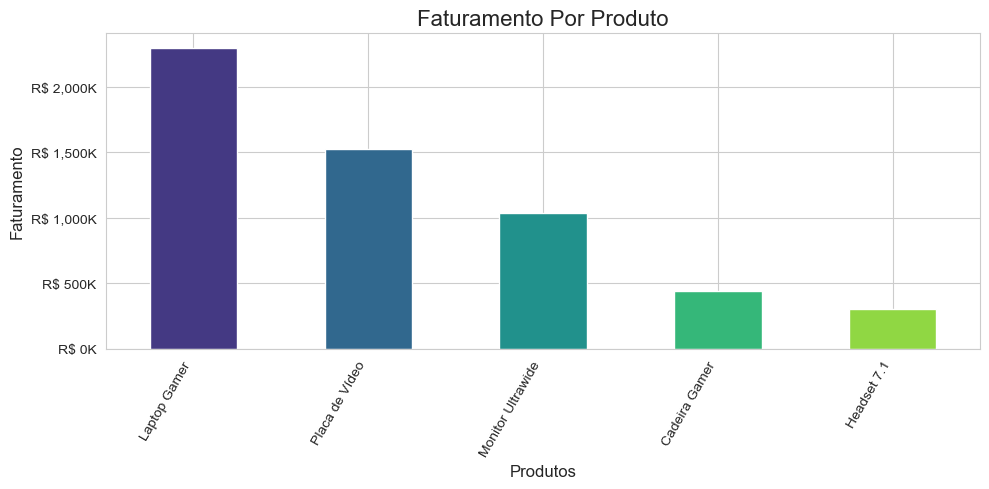

In [15]:
# Ordena os dados para o gráfico ficar mais fácil de ler
faturamento_produto = top_10_faturamento.sort_values(ascending = False)

# Cria a Figura e os Eixos (ax) com plt.subplots()
# Isso nos dá mais controle sobre os elementos do gráfico.
fig, ax = plt.subplots(figsize = (10, 5))

# Cria uma função para formatar os números
# Esta função recebe um valor 'y' e o transforma em uma string no formato 'R$ XX K'
def formatador_milhares(y, pos):
    """Formata o valor em milhares (K) com o cifrão R$."""
    return f'R$ {y/1000:,.0f}K'

# Cria o objeto formatador
formatter = FuncFormatter(formatador_milhares)

# Aplica o formatador ao eixo Y (ax.yaxis)
ax.yaxis.set_major_formatter(formatter)

# Plota os dados usando o objeto 'ax'
faturamento_produto.plot(kind = 'bar', ax = ax, color = sns.color_palette("viridis", len(faturamento_produto)))

# Adiciona títulos e labels usando 'ax.set_...'
ax.set_title('Faturamento Por Produto', fontsize = 16)
ax.set_xlabel('Produtos', fontsize = 12)
ax.set_ylabel('Faturamento', fontsize = 12)

# Ajusta a rotação dos rótulos do eixo X
plt.xticks(rotation = 60, ha = 'right')

plt.savefig('faturamento_produto.png', dpi=300, bbox_inches='tight')

# Garante que tudo fique bem ajustado na imagem final
plt.tight_layout()

# Exibe o gráfico
plt.show()

## Faturamento por Categoria

In [16]:
top_categoria = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending = False).head()

top_categoria

Categoria
Eletrônicos    3336600.00
Hardware       1759500.00
Acessórios      573997.36
Móveis          445200.00
Name: Faturamento, dtype: float64

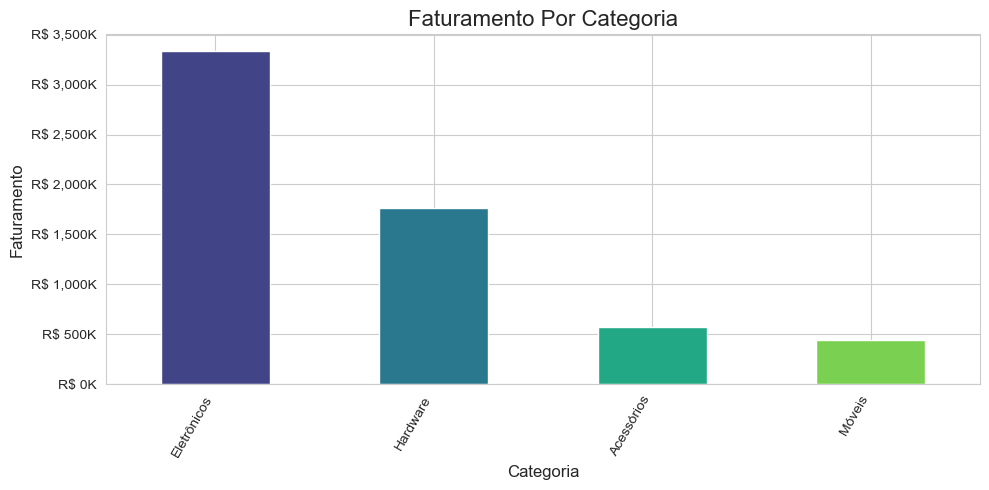

In [17]:
faturamento_categoria = top_categoria.sort_values(ascending = False)

fig, ax = plt.subplots(figsize = (10, 5))

def formatador_milhares(y, pos):
    """Formata o valor em milhares (K) com o cifrão R$."""
    return f'R$ {y/1000:,.0f}K'

formatter = FuncFormatter(formatador_milhares)

ax.yaxis.set_major_formatter(formatter)

faturamento_categoria.plot(kind = 'bar', ax = ax, color = sns.color_palette("viridis", len(faturamento_categoria)))

ax.set_title('Faturamento Por Categoria', fontsize = 16)
ax.set_xlabel('Categoria', fontsize = 12)
ax.set_ylabel('Faturamento', fontsize = 12)

plt.savefig('faturamento_categoria.png', dpi=300, bbox_inches='tight')

plt.xticks(rotation = 60, ha = 'right')

plt.tight_layout()

plt.show()

## Pedido por Estado

In [21]:
pedidos_estado = (df_vendas.groupby('Estado')['ID_Pedido'].count().sort_values(ascending=False))

pedidos_estado

Estado
MG    110
RS    107
CE    103
BA     97
PR     96
SP     94
RJ     93
Name: ID_Pedido, dtype: int64

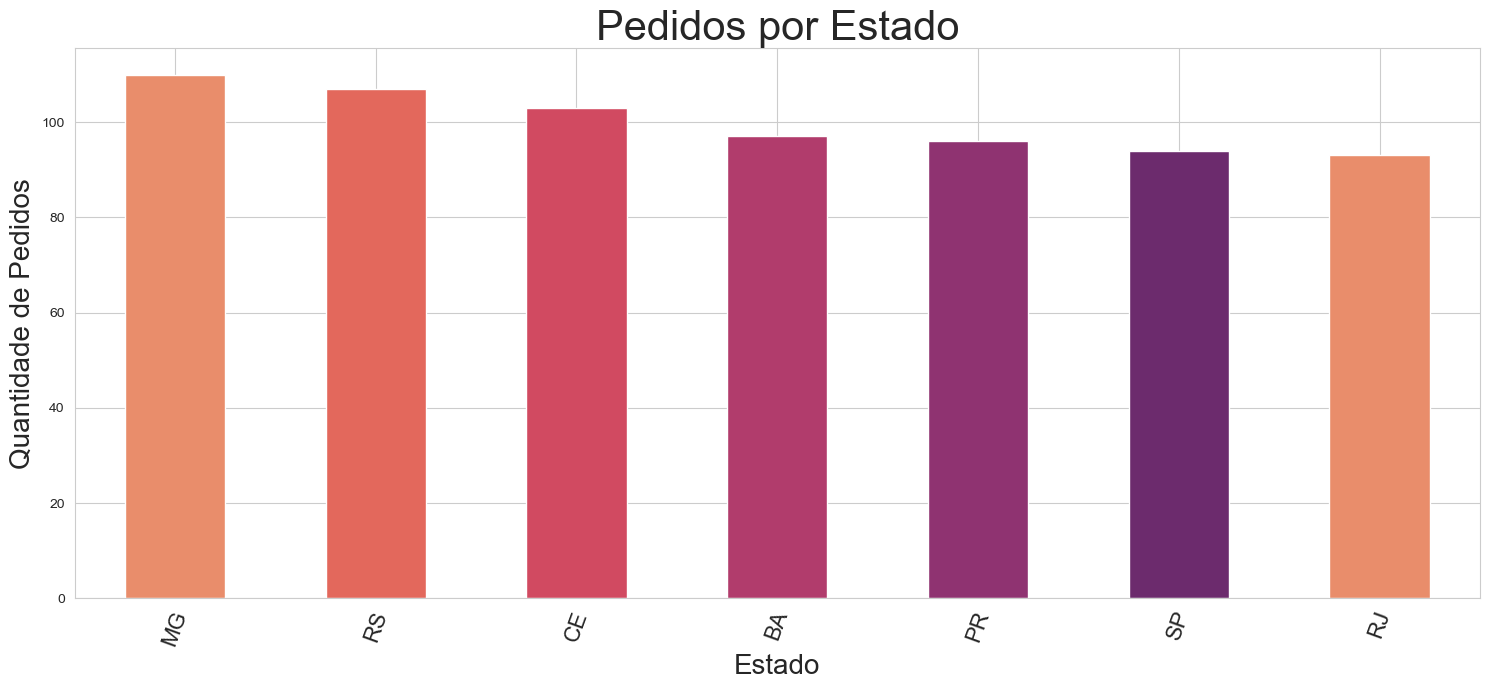

In [23]:
sns.set_style("whitegrid")

plt.figure(figsize = (15, 7))

pedidos_estado.sort_values(ascending = False).plot(kind = 'bar', color = sns.color_palette("flare"))

plt.title('Pedidos por Estado', fontsize = 30)
plt.ylabel('Quantidade de Pedidos', fontsize = 20)
plt.xlabel('Estado', fontsize = 20)
plt.xticks(rotation=70, fontsize=16)

plt.savefig('pedidos_estado.png', dpi=300, bbox_inches='tight')

plt.xticks(rotation = 70)

plt.tight_layout()
plt.show()


## Faturamento por Estado

In [24]:
faturamento_estado = df_vendas.groupby('Estado')['Faturamento'].sum().sort_values(ascending = False).head()

faturamento_estado

Estado
MG    1086724.58
PR     965222.05
RS     878224.24
BA     872392.78
CE     785829.18
Name: Faturamento, dtype: float64

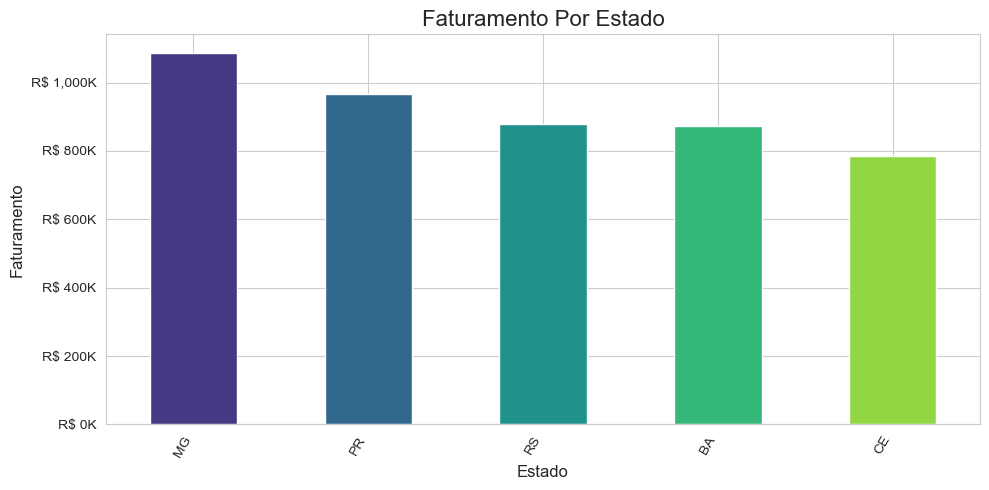

In [25]:
faturamento_por_estado = faturamento_estado.sort_values(ascending = False)

fig, ax = plt.subplots(figsize = (10, 5))

def formatador_milhares(y, pos):
    """Formata o valor em milhares (K) com o cifrão R$."""
    return f'R$ {y/1000:,.0f}K'

formatter = FuncFormatter(formatador_milhares)

ax.yaxis.set_major_formatter(formatter)

faturamento_por_estado.plot(kind = 'bar', ax = ax, color = sns.color_palette("viridis", len(faturamento_por_estado)))

ax.set_title('Faturamento Por Estado', fontsize = 16)
ax.set_xlabel('Estado', fontsize = 12)
ax.set_ylabel('Faturamento', fontsize = 12)

plt.xticks(rotation = 60, ha = 'right')

plt.savefig('faturamento_por_estado.png', dpi=300, bbox_inches='tight')

plt.tight_layout()

plt.show()

## Faturamento Mensal

In [26]:
# Cria uma coluna 'Mes' para facilitar o agrupamento mensal
df_vendas['Mes'] = df_vendas['Data_Pedido'].dt.to_period('M')

In [27]:
# Agrupa por mês e soma o faturamento
faturamento_mensal = df_vendas.groupby('Mes')['Faturamento'].sum()

# Converte o índice para string para facilitar a plotagem no gráfico
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

faturamento_mensal.map('R$ {:,.2f}'.format)

Mes
2026-01    R$ 1,441,293.22
2026-02    R$ 1,193,925.26
2026-03    R$ 1,227,618.01
2026-04    R$ 1,365,817.69
2026-05      R$ 886,643.18
Name: Faturamento, dtype: object

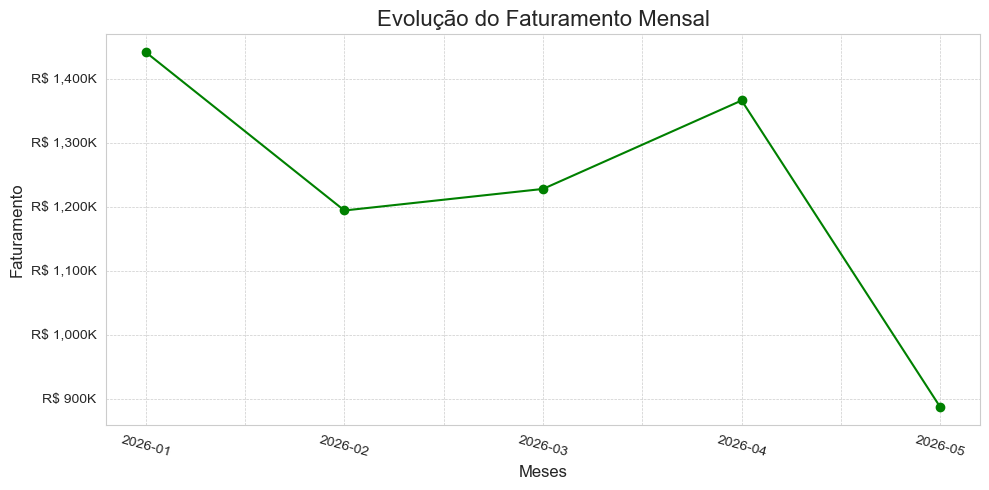

In [28]:
fig, ax = plt.subplots(figsize = (10, 5))

def formatador_milhares(y, pos):
    """Formata o valor em milhares (K) com o cifrão R$."""
    return f'R$ {y/1000:,.0f}K'

formatter = FuncFormatter(formatador_milhares)

ax.yaxis.set_major_formatter(formatter)

faturamento_mensal.plot(kind = 'line', marker = 'o', linestyle = '-', color = 'green')

ax.set_title('Evolução do Faturamento Mensal', fontsize = 16)
ax.set_xlabel('Meses', fontsize = 12)
ax.set_ylabel('Faturamento', fontsize = 12)

plt.xticks(rotation = -15)

plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)

plt.savefig('faturamento_mensal.png', dpi=300, bbox_inches='tight')

plt.tight_layout()

plt.show()

## Status de Pedido

In [29]:
status_entrega = (df_vendas['Status_Entrega'].value_counts())

status_entrega

Status_Entrega
Entrega Lenta     307
Entrega Rápida    297
Entrega Normal     96
Name: count, dtype: int64

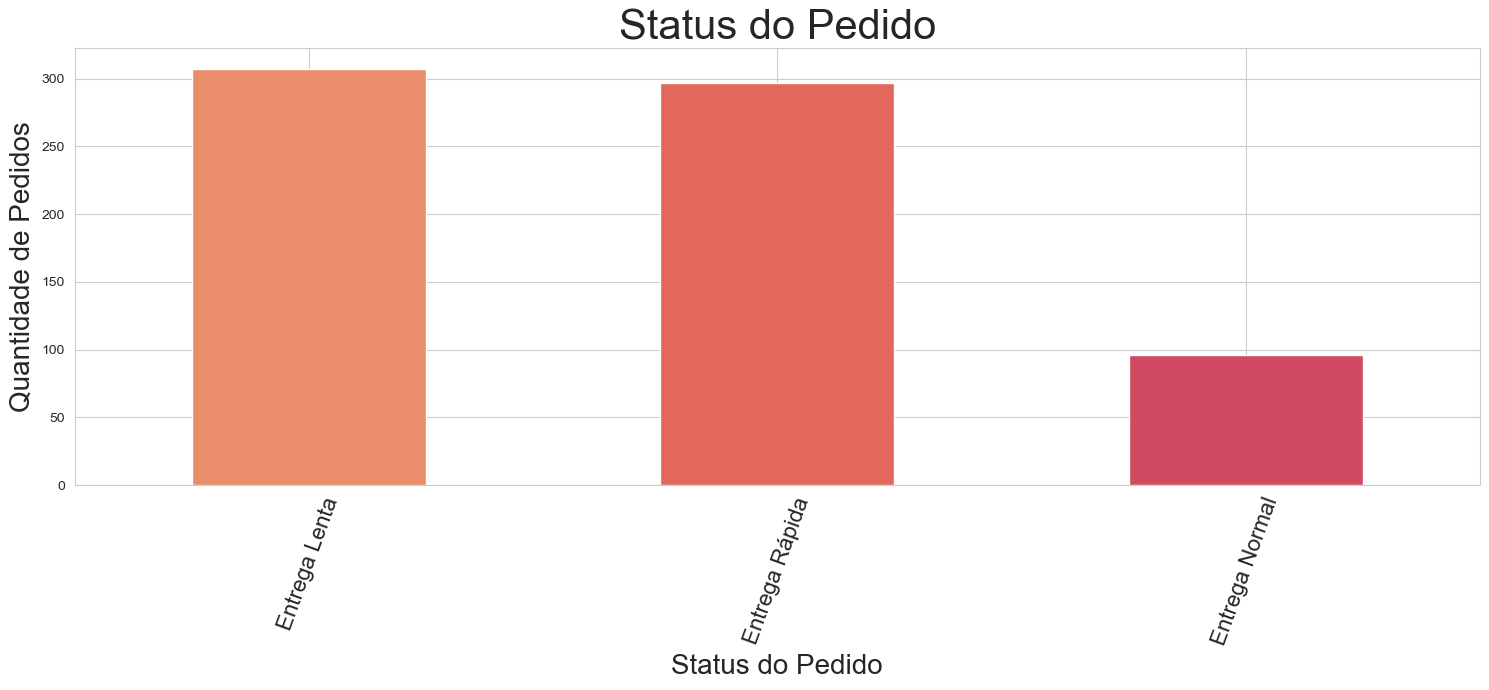

In [30]:
sns.set_style("whitegrid")

plt.figure(figsize = (15, 7))

status_entrega.sort_values(ascending = False).plot(kind = 'bar', color = sns.color_palette("flare"))

plt.title('Status do Pedido', fontsize = 30)
plt.ylabel('Quantidade de Pedidos', fontsize = 20)
plt.xlabel('Status do Pedido', fontsize = 20)
plt.xticks(rotation=70, fontsize=16)

plt.xticks(rotation = 70)

plt.savefig('status_entrega.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()